# Repelling and attracting LCS as strain tensor lines

The FTLE map (see `cabo_verde_ftle`) shows *where* the flow stretches, but not
the material curves themselves. Haller (2015, §5.1 / Table 1) constructs those
curves directly from the Cauchy–Green strain tensor
$C = (\nabla F)^\top \nabla F$, whose eigenpairs satisfy
$C\,\xi_i = \lambda_i\,\xi_i$ with $0 < \lambda_1 \le \lambda_2$ and
$\xi_1 \perp \xi_2$. A **repelling** LCS is a *shrink line* — a curve tangent
to $\xi_1$, i.e. orthogonal to the strong-stretch direction $\xi_2$ that the
FTLE ridge marks. It solves the ODE $\dot r = \xi_1(r)$.

Attracting LCS come from the forward–backward duality (Haller & Sapsis 2011):
an **attracting** LCS is just a repelling LCS of the *backward* flow. So we run
the flow both ways from the same initial grid and, in each, integrate the
$\xi_1$ shrink lines:

- **repelling** LCS = shrink lines of the **forward** $C$;
- **attracting** LCS = shrink lines of the **backward** $C$.

We anchor the analysis at the middle of the bundled window ($t_0$ =
2025-08-06, $T = \pm 5$ d) so both runs stay inside the data. It reads the
bundled current subset, so it runs offline — no CMEMS credentials. Run with
`pixi run -e examples jupytext --sync --execute examples/cabo_verde_lcs.py`.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from parcels import FieldSet, ParticleSet, Particle, StatusCode
from parcels.kernels import AdvectionRK4
from parcels.convert import copernicusmarine_to_sgrid

from lcs_parcels import NeighborSeed, ftle_ridge_seeds, shrink_lines

/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_40688/3746538781.py:5: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  from parcels import FieldSet, ParticleSet, Particle, StatusCode


## Currents

The same CMEMS hourly surface velocity as `cabo_verde_ftle`, saved to a file
so the notebook is self-contained. `copernicusmarine_to_sgrid` +
`from_sgrid_conventions` wrap it as a spherical `FieldSet`.

In [2]:
currents = xr.open_dataset("data/cabo_verde_currents_hourly.nc")
sgrid = copernicusmarine_to_sgrid(fields={"U": currents["uo"], "V": currents["vo"]})
fieldset = FieldSet.from_sgrid_conventions(sgrid, mesh="spherical")
z_surface = float(currents["depth"].values[0])

## Seed and advect both ways

A rectilinear `NeighborSeed` over the release box emits one particle per grid
point. The recovery kernel turns lost particles into `NaN` in place so losses
propagate. We advect the same grid forward and backward for $|T|$ and ingest
each into a `FlowMap`.

In [3]:
t0 = np.datetime64("2025-08-06")
T = np.timedelta64(5, "D")
resolution_deg = 1 / 25
seed_lon, seed_lat = (-27.0, -21.0), (13.5, 18.5)

lon_axis = np.arange(seed_lon[0], seed_lon[1] + 1e-9, resolution_deg)
lat_axis = np.arange(seed_lat[0], seed_lat[1] + 1e-9, resolution_deg)
seed = NeighborSeed.from_axes(lon_axis, lat_axis)

In [4]:
def set_lost_to_nan(particles, fieldset):
    lost = particles.state >= StatusCode.Error
    particles.x = np.where(lost, np.nan, particles.x)
    particles.y = np.where(lost, np.nan, particles.y)
    particles.state = np.where(lost, StatusCode.EndofLoop, particles.state)


def advect(signed_T):
    """Advect the seed grid over the signed window; return the FlowMap."""
    lon, lat = seed.to_parcels_pset()
    pset = ParticleSet(
        fieldset, pclass=Particle,
        x=lon, y=lat, z=np.full(len(lon), z_surface), t=np.full(len(lon), t0),
    )
    dt = np.timedelta64(1, "h") if signed_T > np.timedelta64(0) else np.timedelta64(-1, "h")
    pset.execute(
        [AdvectionRK4, set_lost_to_nan],
        dt=dt, runtime=abs(signed_T), verbose_progress=False,
    )
    return seed.pset_to_flowmap(pset.x, pset.y, t0=t0, t1=t0 + signed_T)


forward = advect(+T)
backward = advect(-T)

## FTLE

The forward FTLE (from $\lambda_2$ of the forward $C$) is the deformation
backdrop and marks where repelling LCS live; the backward FTLE does the same
for attracting LCS. We start each family from the local maxima of its own FTLE.

In [5]:
def ftle_per_day(flowmap):
    return (flowmap.ftle() * 86400.0).rename("FTLE")


ftle_forward = ftle_per_day(forward)
ftle_backward = ftle_per_day(backward)

## Extract the LCS

The tensor-line machinery lives in the package. `ftle_ridge_seeds` picks start
points at the FTLE ridge tops ($7\times7$ local maxima above the 90th percentile), and
`shrink_lines` integrates the $\xi_1$ tensor lines through them. Repelling vs
attracting is just *which* flow map you pass: the forward one gives repelling
LCS, the backward one gives attracting LCS (Haller–Sapsis duality). The stop
guard and the tensor-interpolation choice are documented on `shrink_lines`.

In [6]:
repelling_seeds = ftle_ridge_seeds(ftle_forward)
attracting_seeds = ftle_ridge_seeds(ftle_backward)
repelling = shrink_lines(forward, *repelling_seeds)
attracting = shrink_lines(backward, *attracting_seeds)
print(f"{repelling.sizes['line']} repelling, {attracting.sizes['line']} attracting lines")

54 repelling, 51 attracting lines


## LCS over the FTLE

Each family on its own FTLE, with the seed points dotted so we can check they
sit on the ridge tops and stay well separated.

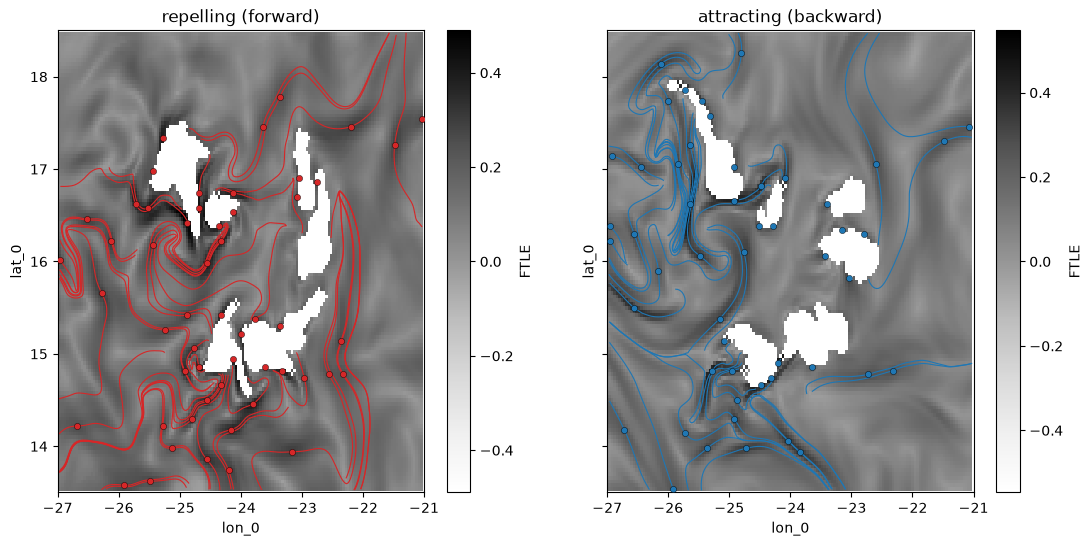

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
panels = [
    (axes[0], ftle_forward, repelling, repelling_seeds, "tab:red", "repelling (forward)"),
    (axes[1], ftle_backward, attracting, attracting_seeds, "tab:blue", "attracting (backward)"),
]
for ax, ftle, lines, seeds, color, name in panels:
    ftle.plot.pcolormesh(x="lon_0", y="lat_0", ax=ax, cmap="Greys", add_colorbar=True)
    for lon_line, lat_line in zip(lines["lon"], lines["lat"]):
        ax.plot(lon_line, lat_line, color=color, lw=0.8)
    seed_lon_pts, seed_lat_pts = seeds
    ax.scatter(seed_lon_pts, seed_lat_pts, s=20, color=color, edgecolor="k", linewidth=0.3, zorder=3)
    ax.set_title(name)
    ax.set_xlim(seed_lon)
    ax.set_ylim(seed_lat)